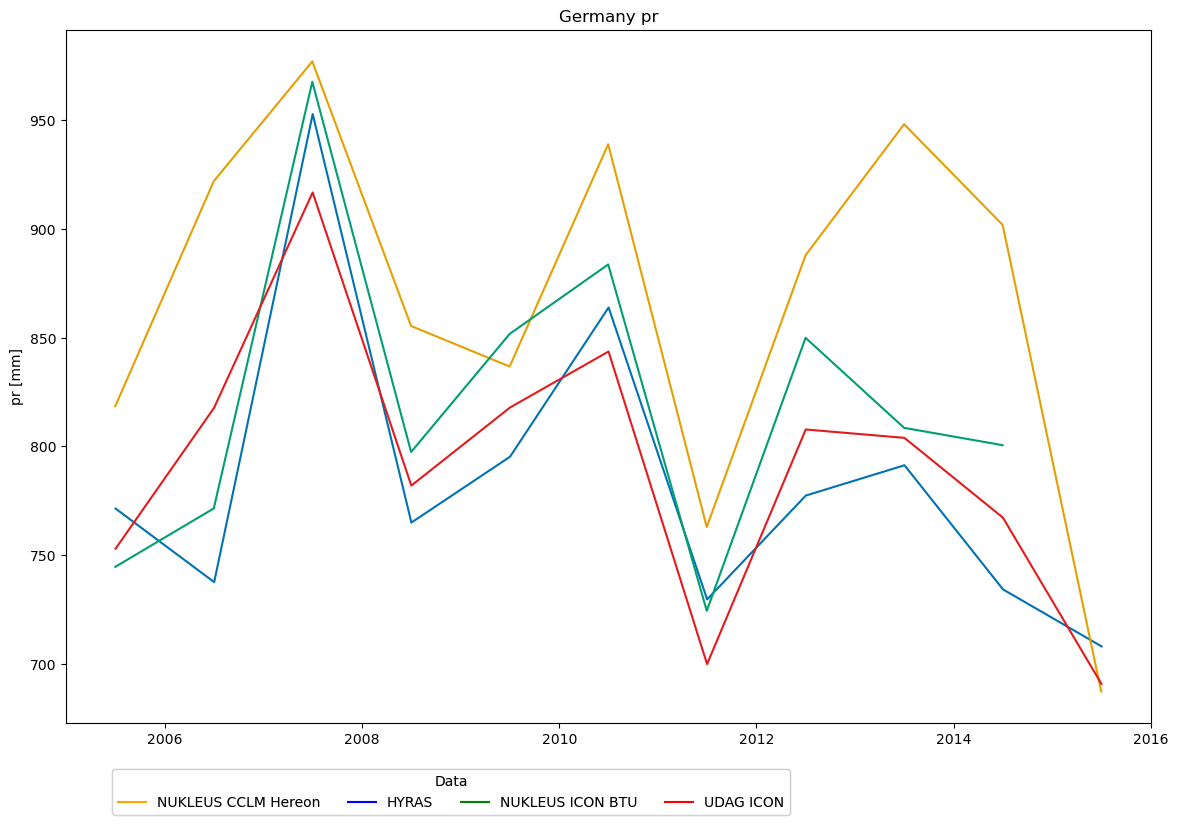

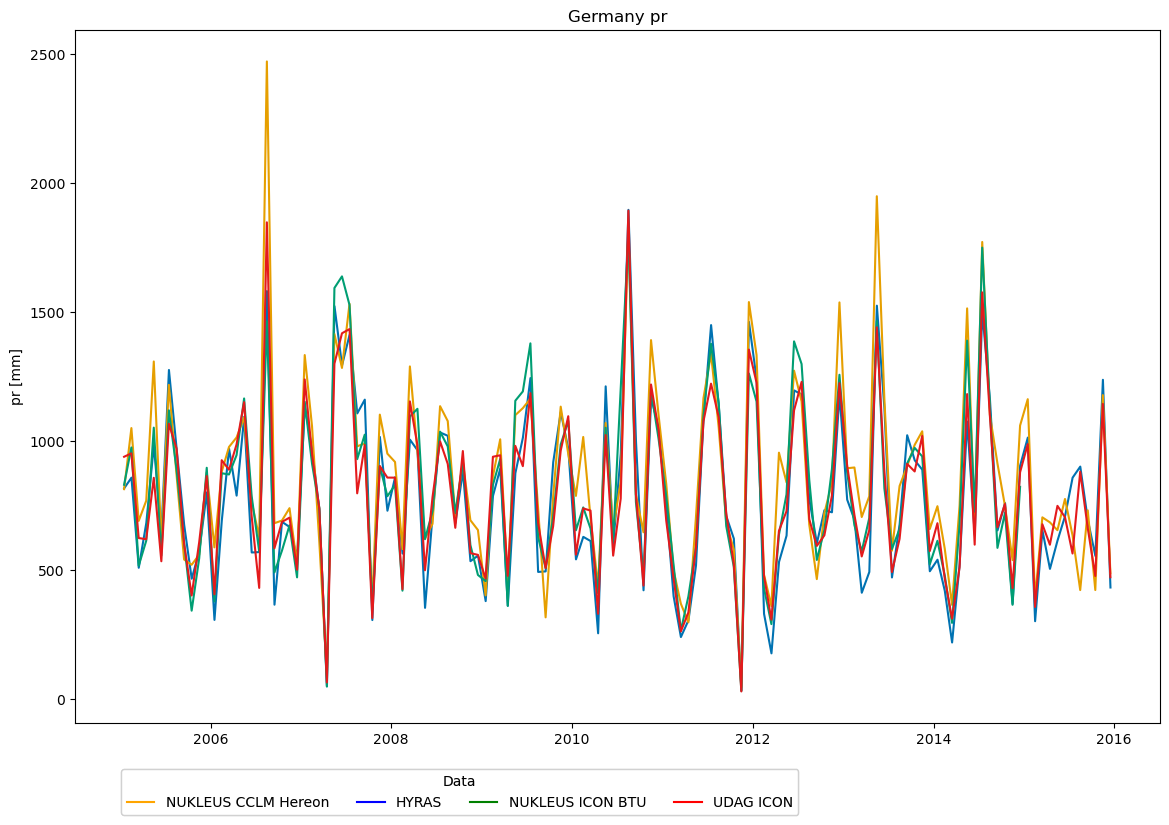

In [ ]:
# Hyras original (original daily, now mean yearly):
# pr:long_name = "Daily Precipitation Sum" ;
# pr:cell_methods = "time: sum" ;
# pr:units = "mm" ;

# UDAG eval (hourly original, now mean yearly):
# pr:standard_name = "precipitation_amount" ;
# pr:long_name = "total precip" ;
# pr:units = "kg m-2" ;
# pr:grid_mapping = "rotated_pole" ;
# pr:coordinates = "lat lon" ;
# pr:_FillValue = -1.e+20f ;
# pr:missing_value = -1.e+20f ;
# pr:cell_methods = "time: sum" ;

# NUKLEUS data (monthly original, now mean yearly):
# pr:_FillValue = 1.e+20f ;
# pr:grid_mapping = "rotated_pole" ;
# pr:standard_name = "precipitation_flux" ;
# pr:long_name = "Precipitation" ;
# pr:units = "kg m-2 s-1" ;

import json

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def find_number_of_days_for_year(df):
    timeseries = []
    for year in df["time"].dt.year:
        timeseries.append(pd.Timestamp(year.item(), 12, 31).dayofyear)
    return timeseries


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name}")
    with xr.open_dataset(hyras_path) as df:
        df = df.sel(time=slice("2005", "2015"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name] / 3600 * find_number_of_days_for_year(df)),
            linestyle="solid",
            color=TOL_COLORS["blue"],
        )

    with xr.open_dataset(nukleus_hereon) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]) * find_number_of_days_for_year(df) * 86400,
            linestyle="solid",
            color=TOL_COLORS["orange"],
        )

    with xr.open_dataset(nukleus_btu) as df:
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]) * find_number_of_days_for_year(df) * 86400,
            linestyle="solid",
            color=TOL_COLORS["green"],
        )

    with xr.open_dataset(udag_eval) as df:
        df = df.sel(time=slice("2005", "2015"))
        ax.plot(
            np.squeeze(df["time"]),
            np.squeeze(df[var_name]) * find_number_of_days_for_year(df) * 24,
            linestyle="solid",
            color=TOL_COLORS["red"],
        )
    ax.set_ylabel("pr [mm]")


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "pr": load_json_file(f"{base_path}/NUKLEUS_Germany_pr_info.json"),
    },
    "HYRAS": {
        "pr": load_json_file(f"{base_path}/HYRAS_Germany_pr_info.json"),
    },
    "UDAG": {
        "pr": load_json_file(f"{base_path}/UDAG_Germany_pr_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(1, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes,
        files["HYRAS"]["pr"][freq],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["pr"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "pr",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "HYRAS": "blue",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/EVAL_HYRAS_pr_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


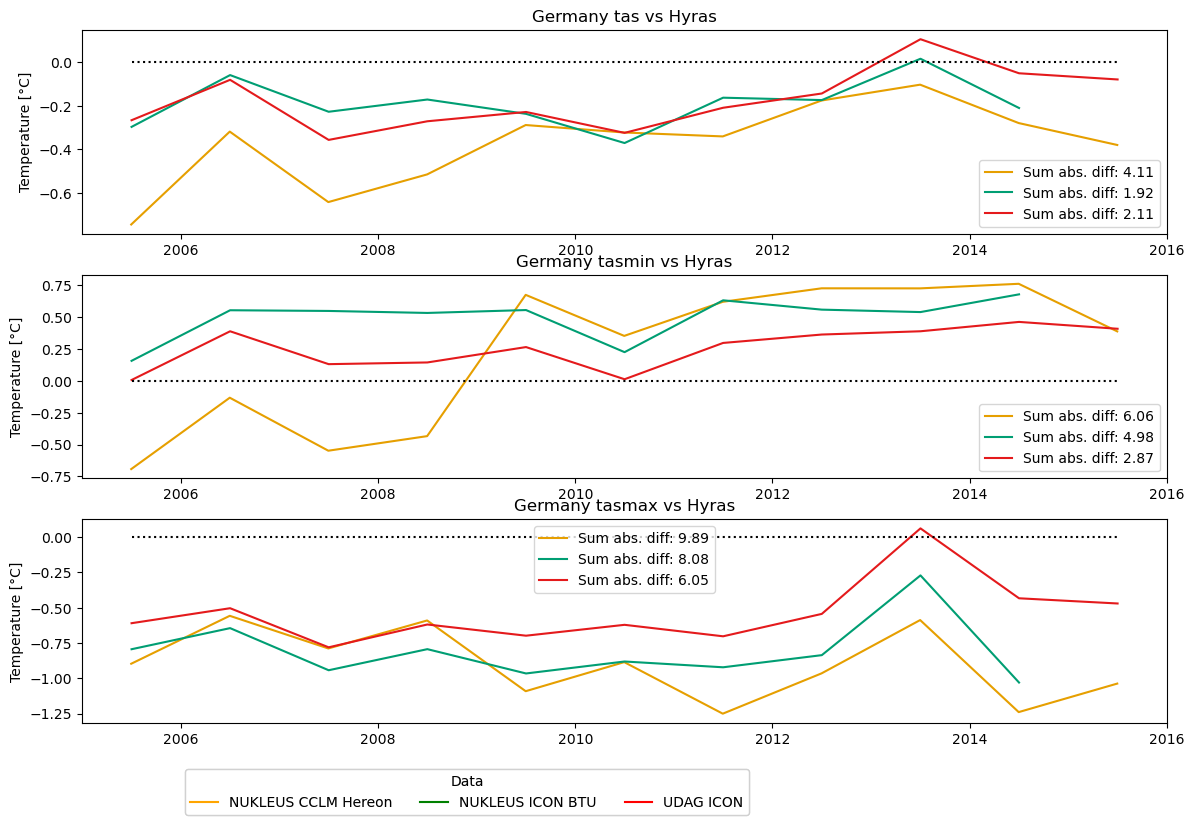

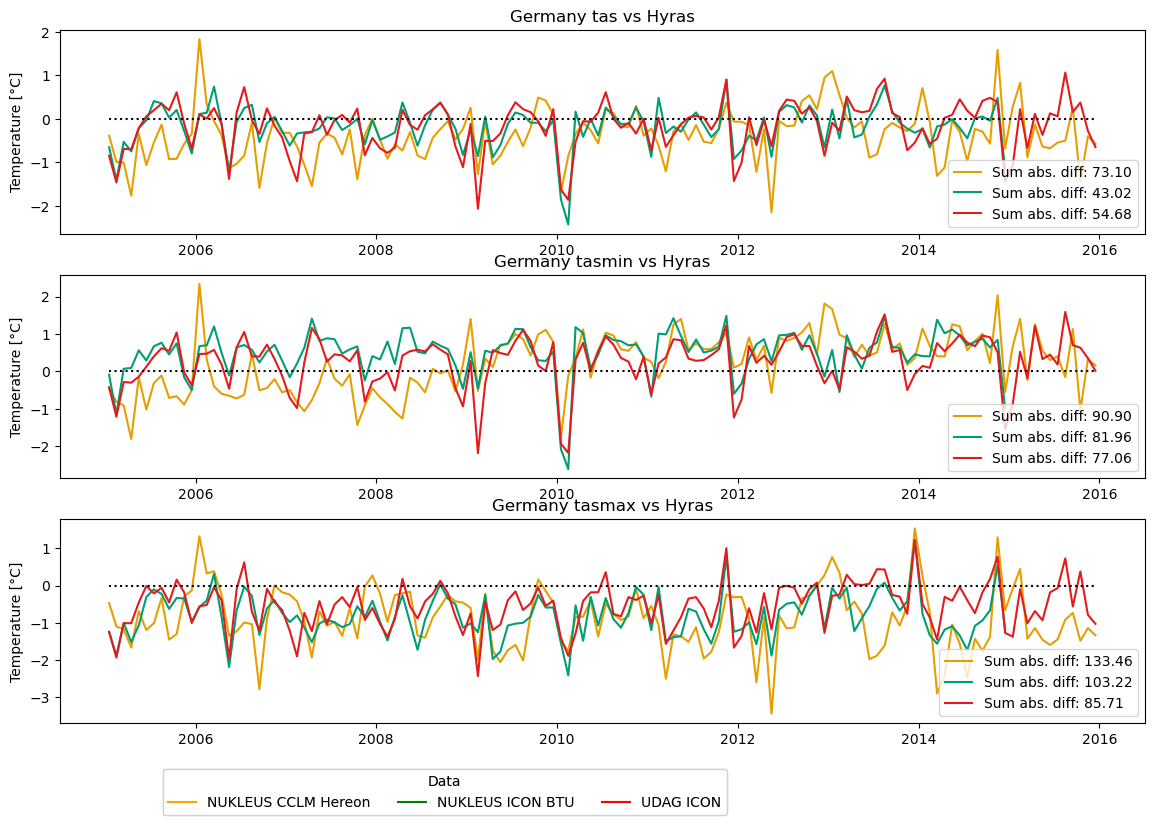

In [ ]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def plot_variable(ax, hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name):
    TOL_COLORS = {
        "blue": "#0072B2",
        "orange": "#E69F00",
        "green": "#009E73",
        "red": "#e41a1c",
    }

    ax.set_title(f"Germany {var_name} vs Hyras")
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2015"))
        with xr.open_dataset(nukleus_hereon) as df:
            diff = (np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),)
            ax.plot(
                np.squeeze(df["time"]),
                np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values),
                linestyle="solid",
                color=TOL_COLORS["orange"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(nukleus_btu) as df:
            diff = (
                np.squeeze(df[var_name].values)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
            )
            ax.plot(
                np.squeeze(dx["time"][0 : len(np.squeeze(df[var_name].values))]),
                np.squeeze(df[var_name].values)
                - np.squeeze(
                    dx[var_name].values[0 : len(np.squeeze(df[var_name].values))]
                ),
                linestyle="solid",
                color=TOL_COLORS["green"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2015"))
            diff = np.squeeze(df[var_name].values) - np.squeeze(dx[var_name].values)
            ax.plot(
                np.squeeze(df["time"]),
                diff,
                linestyle="solid",
                color=TOL_COLORS["red"],
                label=f"Mean abs. diff: {np.mean(np.abs(diff)):.2f}",
            )
            ax.plot(df["time"], [0] * len(df["time"]), linestyle=":", color="black")
    ax.set_ylabel("pr [mm]")
    ax.legend()


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "pr": load_json_file(f"{base_path}/NUKLEUS_Germany_pr_info.json"),
    },
    "HYRAS": {
        "pr": load_json_file(f"{base_path}/HYRAS_Germany_pr_info.json"),
    },
    "UDAG": {
        "pr": load_json_file(f"{base_path}/UDAG_Germany_pr_info.json"),
    },
}

for freq in ["yearly", "mon"]:
    fig, axes = plt.subplots(1, 1, figsize=(14, 9))  # , sharex=True, sharey=True)

    plot_variable(
        axes,
        files["HYRAS"]["pr"][freq],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"]["pr"][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"]["pr"][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        "pr",
    )

    scenario_color = {
        "NUKLEUS CCLM Hereon": "orange",
        "NUKLEUS ICON BTU": "green",
        "UDAG ICON": "red",
    }
    handles = [
        mlines.Line2D([], [], color=scenario_color[s], linestyle="solid", label=s)
        for s in scenario_color
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.4, -0.00),
        ncol=len(handles),
        title="Data",
    )
    fig.add_artist(legend)
    plt.savefig(
        f"/work/bb1364/g260190_heinrich/UDAG/Visualisation/Diff_EVAL_HYRAS_pr_{freq}.png",
        bbox_inches="tight",
        format="png",
        dpi=300,
    )
    plt.show()


In [ ]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt


def load_json_file(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def mean_abs_diff(hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq):
    freq = "3 day mean"
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
            )
            print(
                f"Mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                np.squeeze(df[var_name].values - 273.15)
                - np.squeeze(dx[var_name].values),
            )
            print(
                f"Mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = np.squeeze(df[list(df.keys())[1]].values - 273.15) - np.squeeze(
                dx[var_name].values
            )
            print(f"Mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}")


def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


def three_day_mean_abs_diff(
    hyras_path, nukleus_hereon, nukleus_btu, udag_eval, var_name, freq
):
    with xr.open_dataset(hyras_path) as dx:
        dx = dx.sel(time=slice("2005", "2014"))
        with xr.open_dataset(nukleus_hereon) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values - 273.15), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus Hereon {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(nukleus_btu) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = (
                moving_average(np.squeeze(df[var_name].values - 273.15), 3)
                - moving_average(np.squeeze(dx[var_name].values), 3),
            )
            print(
                f"Moving mean abs. diff Nukleus BTU {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )

        with xr.open_dataset(udag_eval) as df:
            df = df.sel(time=slice("2005", "2014"))
            diff = moving_average(
                np.squeeze(df[list(df.keys())[1]].values - 273.15), 3
            ) - moving_average(np.squeeze(dx[var_name].values), 3)
            print(
                f"Moving mean abs. diff UDAG {variable} {freq}: {np.mean(np.abs(diff)):.2f}"
            )


base_path = "/work/bb1364/g260190_heinrich/UDAG/Data/json_files"

files = {
    "NUKLEUS": {
        "tas": load_json_file(f"{base_path}/NUKLEUS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/NUKLEUS_Germany_tasmax_info.json"),
    },
    "HYRAS": {
        "tas": load_json_file(f"{base_path}/HYRAS_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/HYRAS_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/HYRAS_Germany_tasmax_info.json"),
    },
    "UDAG": {
        "tas": load_json_file(f"{base_path}/UDAG_Germany_tas_info.json"),
        "tasmin": load_json_file(f"{base_path}/UDAG_Germany_tasmin_info.json"),
        "tasmax": load_json_file(f"{base_path}/UDAG_Germany_tasmax_info.json"),
    },
}

for variable in ["tas", "tasmin", "tasmax"]:
    for freq in ["yearly", "mon", "day"]:
        mean_abs_diff(
            files["HYRAS"][variable][freq],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
            files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
            files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
            variable,
            freq,
        )

    three_day_mean_abs_diff(
        files["HYRAS"][variable][freq],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][1],
        files["NUKLEUS"][variable][freq]["ERA5"]["evaluation"]["CEU-3"][0],
        files["UDAG"][variable][freq]["ERA5"]["evaluation"]["MEU-3"][0],
        variable,
        "day",
    )

Mean abs. diff Nukleus Hereon tas 3 day mean: 0.37
Mean abs. diff Nukleus BTU tas 3 day mean: 0.19
Mean abs. diff UDAG tas 3 day mean: 0.20
Mean abs. diff Nukleus Hereon tas 3 day mean: 0.55
Mean abs. diff Nukleus BTU tas 3 day mean: 0.36
Mean abs. diff UDAG tas 3 day mean: 0.41
Mean abs. diff Nukleus Hereon tas 3 day mean: 1.04
Mean abs. diff Nukleus BTU tas 3 day mean: 0.74
Mean abs. diff UDAG tas 3 day mean: 0.79
Moving mean abs. diff Nukleus Hereon tas day: 0.90
Moving mean abs. diff Nukleus BTU tas day: 0.63
Moving mean abs. diff UDAG tas day: 0.69
Mean abs. diff Nukleus Hereon tasmin 3 day mean: 0.57
Mean abs. diff Nukleus BTU tasmin 3 day mean: 0.50
Mean abs. diff UDAG tasmin 3 day mean: 0.25
Mean abs. diff Nukleus Hereon tasmin 3 day mean: 0.69
Mean abs. diff Nukleus BTU tasmin 3 day mean: 0.68
Mean abs. diff UDAG tasmin 3 day mean: 0.58
Mean abs. diff Nukleus Hereon tasmin 3 day mean: 1.26
Mean abs. diff Nukleus BTU tasmin 3 day mean: 1.03
Mean abs. diff UDAG tasmin 3 day mean